# Exploración del Entorno CartPole-v1

Este notebook contiene la exploración inicial del entorno CartPole-v1 de Gymnasium, necesaria para comprender el espacio de observaciones y diseñar una estrategia de discretización adecuada para la implementación de Q-Learning.

## Importación de librerías

In [61]:
import gymnasium as gym
import numpy as np
import random

In [62]:
# Inicializar el entorno en modo sin visualización para análisis
env = gym.make('CartPole-v1', render_mode=None)

## Análisis del espacio de observaciones

El espacio de observaciones de CartPole-v1 es continuo y contiene 4 variables.

In [63]:
print("Espacio de observaciones:", env.observation_space)
print("Límites inferiores:", env.observation_space.low)
print("Límites superiores:", env.observation_space.high)

Espacio de observaciones: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Límites inferiores: [-4.8               -inf -0.41887903        -inf]
Límites superiores: [4.8               inf 0.41887903        inf]


## Análisis del espacio de acciones

El espacio de acciones determina los movimientos que puede realizar el agente.

In [64]:
print("Espacio de acciones:", env.action_space)
print("Número de acciones:", env.action_space.n)
print("Acción 0: Empujar el carro hacia la izquierda")
print("Acción 1: Empujar el carro hacia la derecha")

Espacio de acciones: Discrete(2)
Número de acciones: 2
Acción 0: Empujar el carro hacia la izquierda
Acción 1: Empujar el carro hacia la derecha


## Exploración de rangos reales de las variables

Dado que los límites teóricos del espacio de observaciones incluyen infinitos, es necesario ejecutar episodios aleatorios para determinar los rangos reales que toman las variables durante el juego. Esta información será fundamental para diseñar una discretización efectiva.

In [65]:
# Ejecutar episodios aleatorios para observar los rangos reales
num_episodes = 100
observations = []

for episode in range(num_episodes):
    obs, _ = env.reset()
    done = False
    
    while not done:
        observations.append(obs)
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

observations = np.array(observations)

# Calcular estadísticas de cada variable
variables = ['Posición del carro', 'Velocidad del carro', 'Ángulo del poste', 'Velocidad angular del poste']
print("Estadísticas de las variables observadas en {} episodios aleatorios:\n".format(num_episodes))

for i, var_name in enumerate(variables):
    print(f"{var_name}:")
    print(f"  Mínimo: {observations[:, i].min():.4f}")
    print(f"  Máximo: {observations[:, i].max():.4f}")
    print(f"  Media: {observations[:, i].mean():.4f}")
    print(f"  Desviación estándar: {observations[:, i].std():.4f}")
    print()

Estadísticas de las variables observadas en 100 episodios aleatorios:

Posición del carro:
  Mínimo: -0.3818
  Máximo: 0.4526
  Media: 0.0018
  Desviación estándar: 0.0760

Velocidad del carro:
  Mínimo: -1.5450
  Máximo: 1.7741
  Media: 0.0423
  Desviación estándar: 0.5184

Ángulo del poste:
  Mínimo: -0.2094
  Máximo: 0.2092
  Media: 0.0020
  Desviación estándar: 0.0888

Velocidad angular del poste:
  Mínimo: -2.6592
  Máximo: 2.3493
  Media: -0.0376
  Desviación estándar: 0.7978



## Análisis de criticidad de las variables

Según la documentación de CartPole-v1, el episodio termina cuando:
- La posición del carro excede ±2.4 unidades
- El ángulo del poste excede ±12 grados (≈ ±0.2095 radianes)

Las variables relacionadas con el ángulo del poste son críticas para mantener el equilibrio, mientras que la posición del carro tiene un margen más amplio.

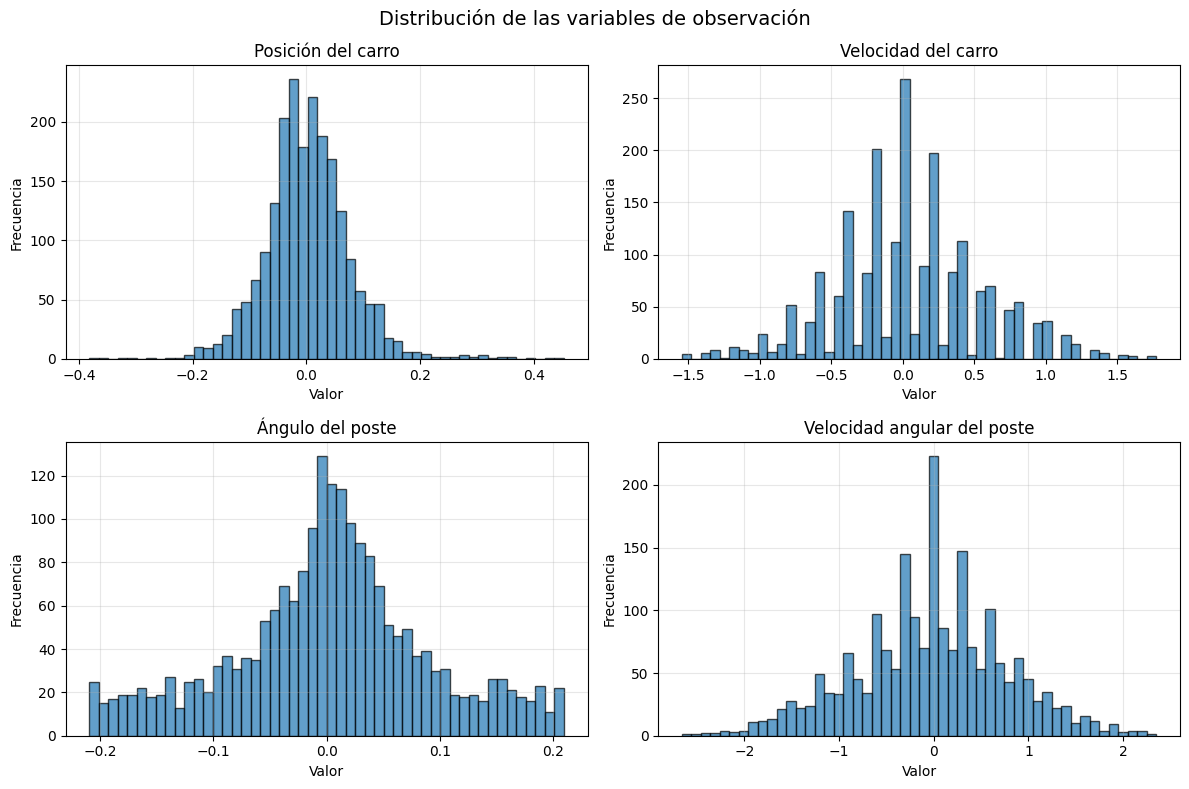

In [66]:
# Visualizar distribución de las variables
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribución de las variables de observación', fontsize=14)

for i, (var_name, ax) in enumerate(zip(variables, axes.flatten())):
    ax.hist(observations[:, i], bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.set_title(var_name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [67]:
# Determinar rangos prácticos para discretización
# Usaremos percentiles para evitar valores extremos que rara vez ocurren

print("Rangos recomendados para discretización (basados en percentiles 1-99):\n")

for i, var_name in enumerate(variables):
    p1 = np.percentile(observations[:, i], 1)
    p99 = np.percentile(observations[:, i], 99)
    print(f"{var_name}:")
    print(f"  Rango sugerido: [{p1:.4f}, {p99:.4f}]")
    print()

Rangos recomendados para discretización (basados en percentiles 1-99):

Posición del carro:
  Rango sugerido: [-0.1783, 0.2261]

Velocidad del carro:
  Rango sugerido: [-1.2117, 1.3501]

Ángulo del poste:
  Rango sugerido: [-0.2034, 0.2012]

Velocidad angular del poste:
  Rango sugerido: [-1.9338, 1.8340]



## Conclusiones de la exploración

Los resultados de esta exploración nos permiten establecer:

1. **Variables críticas**: Ángulo del poste y velocidad angular del poste requieren mayor resolución en la discretización debido a su impacto directo en el equilibrio.

2. **Variables no críticas**: Posición y velocidad del carro pueden discretizarse con menos bins sin perder información esencial.

3. **Estrategia de discretización**: Se implementarán dos versiones:
   - Discretización gruesa: 3 bins para variables no críticas, 6 bins para variables críticas
   - Discretización fina: 6 bins para variables no críticas, 12 bins para variables críticas

## Definición de rangos óptimos para discretización

Basándonos en el análisis realizado, los límites de terminación del entorno y las mejores prácticas, se establecen los siguientes rangos para la discretización:

In [68]:
# Definición de rangos para discretización
# Estos rangos serán utilizados en las implementaciones de Q-Learning

# Variables NO CRÍTICAS (menor impacto en terminación del episodio)
cart_position_range = (-2.4, 2.4)        # Límite exacto de terminación del entorno
cart_velocity_range = (-3.0, 3.0)        # Rango amplio que cubre comportamiento de políticas entrenadas

# Variables CRÍTICAS (impacto directo en equilibrio del poste)
pole_angle_range = (-0.21, 0.21)         # Límite exacto de terminación (±12 grados)
pole_angular_velocity_range = (-3.5, 3.5)  # Rango que captura estados de alta velocidad angular

print("Rangos definidos para discretización:\n")
print(f"Posición del carro: {cart_position_range}")
print(f"Velocidad del carro: {cart_velocity_range}")
print(f"Ángulo del poste: {pole_angle_range}")
print(f"Velocidad angular del poste: {pole_angular_velocity_range}")

Rangos definidos para discretización:

Posición del carro: (-2.4, 2.4)
Velocidad del carro: (-3.0, 3.0)
Ángulo del poste: (-0.21, 0.21)
Velocidad angular del poste: (-3.5, 3.5)


### Justificación de los rangos seleccionados

**Posición del carro** `[-2.4, 2.4]`:
- Corresponde al límite exacto de terminación del entorno
- Aunque en episodios aleatorios no se exploró completamente, un agente entrenado necesitará acceder a todo el rango

**Velocidad del carro** `[-3.0, 3.0]`:
- Rango observado en episodios aleatorios: aproximadamente ±1.9
- Se amplía para capturar velocidades mayores que puede desarrollar un agente entrenado
- Valor conservador que equilibra cobertura y eficiencia de la tabla Q

**Ángulo del poste** `[-0.21, 0.21]` rad (±12°):
- Variable más crítica: el episodio termina si se excede este límite
- Usar el límite exacto asegura que todos los estados válidos estén representados
- Requiere mayor resolución en la discretización

**Velocidad angular del poste** `[-3.5, 3.5]` rad/s:
- Segunda variable crítica: determina si el poste se recupera o continúa cayendo
- Rango observado: aproximadamente ±2.5
- Se amplía para capturar situaciones límite donde el agente debe realizar correcciones agresivas
- Requiere mayor resolución en la discretización

# Implementación de Discretización

En esta sección se implementan dos estrategias de discretización para convertir el espacio de observaciones continuo en estados discretos que permitan la aplicación de Q-Learning.

## Discretización Gruesa

Esta discretización utiliza menor resolución para crear un espacio de estados más compacto:
- Variables no críticas (posición y velocidad del carro): 3 bins
- Variables críticas (ángulo y velocidad angular del poste): 6 bins
- Espacio de estados total: 3 × 3 × 6 × 6 = 324 estados

In [69]:
# Crear bins para discretización gruesa
n_bins_cart_pos_coarse = 3
n_bins_cart_vel_coarse = 3
n_bins_pole_angle_coarse = 6
n_bins_pole_ang_vel_coarse = 6

# Generar los límites de los bins usando linspace
cart_pos_bins_coarse = np.linspace(cart_position_range[0], cart_position_range[1], n_bins_cart_pos_coarse + 1)
cart_vel_bins_coarse = np.linspace(cart_velocity_range[0], cart_velocity_range[1], n_bins_cart_vel_coarse + 1)
pole_angle_bins_coarse = np.linspace(pole_angle_range[0], pole_angle_range[1], n_bins_pole_angle_coarse + 1)
pole_ang_vel_bins_coarse = np.linspace(pole_angular_velocity_range[0], pole_angular_velocity_range[1], n_bins_pole_ang_vel_coarse + 1)

print("Discretización Gruesa:")
print(f"Total de estados: {n_bins_cart_pos_coarse * n_bins_cart_vel_coarse * n_bins_pole_angle_coarse * n_bins_pole_ang_vel_coarse}")
print(f"\nBins por variable:")
print(f"  Posición del carro: {n_bins_cart_pos_coarse} bins")
print(f"  Velocidad del carro: {n_bins_cart_vel_coarse} bins")
print(f"  Ángulo del poste: {n_bins_pole_angle_coarse} bins")
print(f"  Velocidad angular del poste: {n_bins_pole_ang_vel_coarse} bins")

Discretización Gruesa:
Total de estados: 324

Bins por variable:
  Posición del carro: 3 bins
  Velocidad del carro: 3 bins
  Ángulo del poste: 6 bins
  Velocidad angular del poste: 6 bins


In [70]:
# Función para discretizar observaciones (versión gruesa)
def discretize_observation_coarse(observation):
    """
    Convierte una observación continua en un estado discreto usando discretización gruesa.
    
    Args:
        observation: Array de 4 elementos con [posición, velocidad, ángulo, velocidad_angular]
    
    Returns:
        Tupla de 4 enteros representando el estado discreto
    """
    cart_pos, cart_vel, pole_angle, pole_ang_vel = observation
    
    # Usar digitize para encontrar el bin correspondiente (restamos 1 para indexar desde 0)
    cart_pos_idx = np.digitize(cart_pos, cart_pos_bins_coarse[1:-1])
    cart_vel_idx = np.digitize(cart_vel, cart_vel_bins_coarse[1:-1])
    pole_angle_idx = np.digitize(pole_angle, pole_angle_bins_coarse[1:-1])
    pole_ang_vel_idx = np.digitize(pole_ang_vel, pole_ang_vel_bins_coarse[1:-1])
    
    return (cart_pos_idx, cart_vel_idx, pole_angle_idx, pole_ang_vel_idx)

In [71]:
# Verificar funcionamiento de la discretización gruesa
test_obs, _ = env.reset()
print("Observación continua de prueba:")
print(f"  Posición: {test_obs[0]:.4f}")
print(f"  Velocidad: {test_obs[1]:.4f}")
print(f"  Ángulo: {test_obs[2]:.4f}")
print(f"  Velocidad angular: {test_obs[3]:.4f}")

test_state = discretize_observation_coarse(test_obs)
print(f"\nEstado discreto resultante: {test_state}")
print(f"Índices válidos: cart_pos[0-{n_bins_cart_pos_coarse-1}], cart_vel[0-{n_bins_cart_vel_coarse-1}], pole_angle[0-{n_bins_pole_angle_coarse-1}], pole_ang_vel[0-{n_bins_pole_ang_vel_coarse-1}]")

Observación continua de prueba:
  Posición: 0.0185
  Velocidad: 0.0100
  Ángulo: 0.0322
  Velocidad angular: 0.0424

Estado discreto resultante: (np.int64(1), np.int64(1), np.int64(3), np.int64(3))
Índices válidos: cart_pos[0-2], cart_vel[0-2], pole_angle[0-5], pole_ang_vel[0-5]


## Discretización Fina

Esta discretización utiliza mayor resolución para capturar más detalles del espacio de estados:
- Variables no críticas (posición y velocidad del carro): 6 bins
- Variables críticas (ángulo y velocidad angular del poste): 12 bins
- Espacio de estados total: 6 × 6 × 12 × 12 = 5,184 estados

In [72]:
# Crear bins para discretización fina
n_bins_cart_pos_fine = 6
n_bins_cart_vel_fine = 6
n_bins_pole_angle_fine = 12
n_bins_pole_ang_vel_fine = 12

# Generar los límites de los bins usando linspace
cart_pos_bins_fine = np.linspace(cart_position_range[0], cart_position_range[1], n_bins_cart_pos_fine + 1)
cart_vel_bins_fine = np.linspace(cart_velocity_range[0], cart_velocity_range[1], n_bins_cart_vel_fine + 1)
pole_angle_bins_fine = np.linspace(pole_angle_range[0], pole_angle_range[1], n_bins_pole_angle_fine + 1)
pole_ang_vel_bins_fine = np.linspace(pole_angular_velocity_range[0], pole_angular_velocity_range[1], n_bins_pole_ang_vel_fine + 1)

print("Discretización Fina:")
print(f"Total de estados: {n_bins_cart_pos_fine * n_bins_cart_vel_fine * n_bins_pole_angle_fine * n_bins_pole_ang_vel_fine}")
print(f"\nBins por variable:")
print(f"  Posición del carro: {n_bins_cart_pos_fine} bins")
print(f"  Velocidad del carro: {n_bins_cart_vel_fine} bins")
print(f"  Ángulo del poste: {n_bins_pole_angle_fine} bins")
print(f"  Velocidad angular del poste: {n_bins_pole_ang_vel_fine} bins")

Discretización Fina:
Total de estados: 5184

Bins por variable:
  Posición del carro: 6 bins
  Velocidad del carro: 6 bins
  Ángulo del poste: 12 bins
  Velocidad angular del poste: 12 bins


In [73]:
# Función para discretizar observaciones (versión fina)
def discretize_observation_fine(observation):
    """
    Convierte una observación continua en un estado discreto usando discretización fina.
    
    Args:
        observation: Array de 4 elementos con [posición, velocidad, ángulo, velocidad_angular]
    
    Returns:
        Tupla de 4 enteros representando el estado discreto
    """
    cart_pos, cart_vel, pole_angle, pole_ang_vel = observation
    
    # Usar digitize para encontrar el bin correspondiente (restamos 1 para indexar desde 0)
    cart_pos_idx = np.digitize(cart_pos, cart_pos_bins_fine[1:-1])
    cart_vel_idx = np.digitize(cart_vel, cart_vel_bins_fine[1:-1])
    pole_angle_idx = np.digitize(pole_angle, pole_angle_bins_fine[1:-1])
    pole_ang_vel_idx = np.digitize(pole_ang_vel, pole_ang_vel_bins_fine[1:-1])
    
    return (cart_pos_idx, cart_vel_idx, pole_angle_idx, pole_ang_vel_idx)

In [74]:
# Verificar funcionamiento de la discretización fina
test_state_fine = discretize_observation_fine(test_obs)
print("Misma observación continua de prueba:")
print(f"  Posición: {test_obs[0]:.4f}")
print(f"  Velocidad: {test_obs[1]:.4f}")
print(f"  Ángulo: {test_obs[2]:.4f}")
print(f"  Velocidad angular: {test_obs[3]:.4f}")

print(f"\nEstado discreto resultante: {test_state_fine}")
print(f"Índices válidos: cart_pos[0-{n_bins_cart_pos_fine-1}], cart_vel[0-{n_bins_cart_vel_fine-1}], pole_angle[0-{n_bins_pole_angle_fine-1}], pole_ang_vel[0-{n_bins_pole_ang_vel_fine-1}]")

Misma observación continua de prueba:
  Posición: 0.0185
  Velocidad: 0.0100
  Ángulo: 0.0322
  Velocidad angular: 0.0424

Estado discreto resultante: (np.int64(3), np.int64(3), np.int64(6), np.int64(6))
Índices válidos: cart_pos[0-5], cart_vel[0-5], pole_angle[0-11], pole_ang_vel[0-11]


## Comparación de las Discretizaciones

La discretización gruesa ofrece un espacio de estados 16 veces más pequeño (324 vs 5,184), lo que implica:

**Ventajas de la discretización gruesa:**
- Convergencia más rápida durante el entrenamiento
- Menor uso de memoria
- Más adecuada para exploración inicial

**Ventajas de la discretización fina:**
- Mayor precisión en la representación de estados
- Puede capturar diferencias sutiles importantes para el control
- Potencialmente mejor performance final

Ambas discretizaciones priorizan las variables críticas (ángulo y velocidad angular del poste) con el doble de bins que las variables no críticas.

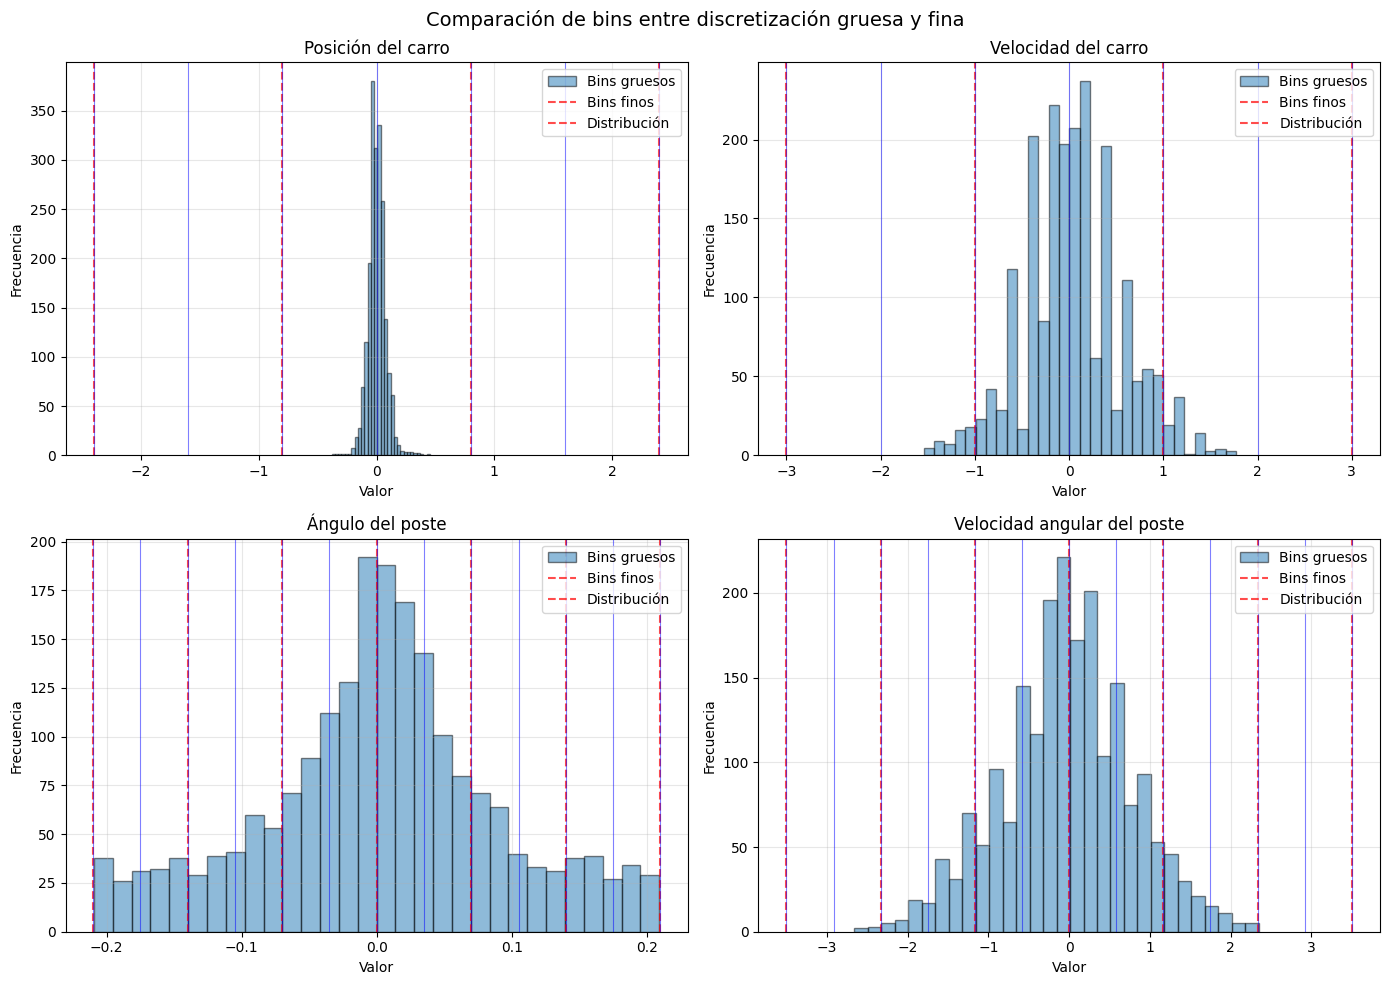

  Líneas rojas discontinuas: Límites de bins en discretización gruesa
  Líneas azules continuas: Límites de bins en discretización fina


In [75]:
# Visualizar diferencia en granularidad entre discretizaciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación de bins entre discretización gruesa y fina', fontsize=14)

bins_coarse = [cart_pos_bins_coarse, cart_vel_bins_coarse, pole_angle_bins_coarse, pole_ang_vel_bins_coarse]
bins_fine = [cart_pos_bins_fine, cart_vel_bins_fine, pole_angle_bins_fine, pole_ang_vel_bins_fine]

for i, (var_name, ax) in enumerate(zip(variables, axes.flatten())):
    # Histograma de las observaciones
    ax.hist(observations[:, i], bins=30, alpha=0.5, edgecolor='black', label='Distribución observada')
    
    # Líneas verticales para bins gruesos
    for bin_edge in bins_coarse[i]:
        ax.axvline(bin_edge, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Líneas verticales para bins finos
    for bin_edge in bins_fine[i]:
        ax.axvline(bin_edge, color='blue', linestyle='-', linewidth=0.8, alpha=0.5)
    
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.set_title(var_name)
    ax.grid(True, alpha=0.3)
    ax.legend(['Bins gruesos', 'Bins finos', 'Distribución'], loc='upper right')

plt.tight_layout()
plt.show()

print("  Líneas rojas discontinuas: Límites de bins en discretización gruesa")
print("  Líneas azules continuas: Límites de bins en discretización fina")

# Implementación de Q-Learning

En esta sección se implementa el algoritmo de Q-Learning para entrenar un agente que aprenda a mantener el equilibrio del poste sobre el carro.

## Inicialización de la tabla Q

La tabla Q almacena el valor esperado de cada par estado-acción. Se inicializa con ceros y se actualiza durante el entrenamiento.

In [76]:
# Inicializar tabla Q para discretización gruesa
# Dimensiones: (cart_pos, cart_vel, pole_angle, pole_ang_vel, acciones)
Q_table_coarse = np.zeros((
    n_bins_cart_pos_coarse,
    n_bins_cart_vel_coarse,
    n_bins_pole_angle_coarse,
    n_bins_pole_ang_vel_coarse,
    env.action_space.n
))

print(f"Tabla Q inicializada con forma: {Q_table_coarse.shape}")
print(f"Total de valores en la tabla Q: {Q_table_coarse.size}")
print(f"Memoria utilizada: {Q_table_coarse.nbytes / 1024:.2f} KB")

Tabla Q inicializada con forma: (3, 3, 6, 6, 2)
Total de valores en la tabla Q: 648
Memoria utilizada: 5.06 KB


## Funciones de política

Implementación de las políticas de selección de acciones necesarias para el algoritmo.

In [77]:
def epsilon_greedy_policy(state, Q_table, epsilon):
    """
    Selecciona una acción usando la política epsilon-greedy.
    Con probabilidad epsilon explora (acción aleatoria), 
    con probabilidad (1-epsilon) explota (mejor acción conocida).
    
    Args:
        state: Estado discreto actual (tupla de índices)
        Q_table: Tabla Q con los valores de estado-acción
        epsilon: Probabilidad de exploración
    
    Returns:
        Acción seleccionada (0 o 1)
    """
    if np.random.random() < epsilon:
        # Exploración: acción aleatoria
        return env.action_space.sample()
    else:
        # Explotación: mejor acción según Q
        return np.argmax(Q_table[state])


def greedy_policy(state, Q_table):
    """
    Selecciona la mejor acción según los valores actuales de Q.
    Se utiliza durante la evaluación del agente entrenado.
    
    Args:
        state: Estado discreto actual (tupla de índices)
        Q_table: Tabla Q con los valores de estado-acción
    
    Returns:
        Mejor acción (0 o 1)
    """
    return np.argmax(Q_table[state])

## Algoritmo de Q-Learning

Implementación del algoritmo de Q-Learning con la ecuación de actualización:

$$Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma \max_{a'} Q(s',a') - Q(s,a)]$$

Donde:
- $\alpha$ es la tasa de aprendizaje (learning rate)
- $\gamma$ es el factor de descuento (discount factor)
- $r$ es la recompensa obtenida
- $s$ es el estado actual
- $s'$ es el estado siguiente
- $a$ es la acción tomada

In [78]:
def q_learning_train(env, Q_table, discretize_fn, n_episodes, alpha, gamma, 
                     epsilon_start, epsilon_end, epsilon_decay_type='linear'):
    """
    Entrena un agente usando Q-Learning.
    
    Args:
        env: Entorno de Gymnasium
        Q_table: Tabla Q a actualizar
        discretize_fn: Función para discretizar observaciones
        n_episodes: Número de episodios de entrenamiento
        alpha: Tasa de aprendizaje
        gamma: Factor de descuento
        epsilon_start: Epsilon inicial para exploración
        epsilon_end: Epsilon final para exploración
        epsilon_decay_type: Tipo de decaimiento ('linear' o 'exponential')
    
    Returns:
        rewards_history: Lista con recompensas totales por episodio
        steps_history: Lista con pasos por episodio
    """
    rewards_history = []
    steps_history = []
    
    for episode in range(n_episodes):
        # Calcular epsilon para este episodio
        if epsilon_decay_type == 'linear':
            epsilon = epsilon_start - (epsilon_start - epsilon_end) * (episode / n_episodes)
        else:  # exponential
            epsilon = epsilon_end + (epsilon_start - epsilon_end) * np.exp(-episode / (n_episodes * 0.3))
        
        # Inicializar episodio
        obs, _ = env.reset()
        state = discretize_fn(obs)
        total_reward = 0
        steps = 0
        done = False
        
        while not done:
            # Seleccionar acción usando política epsilon-greedy
            action = epsilon_greedy_policy(state, Q_table, epsilon)
            
            # Ejecutar acción
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretize_fn(next_obs)
            
            # Actualizar Q-table usando la ecuación de Q-Learning
            best_next_action = np.argmax(Q_table[next_state])
            td_target = reward + gamma * Q_table[next_state][best_next_action]
            td_error = td_target - Q_table[state][action]
            Q_table[state][action] += alpha * td_error
            
            # Actualizar estado
            state = next_state
            total_reward += reward
            steps += 1
        
        rewards_history.append(total_reward)
        steps_history.append(steps)
        
        # Mostrar progreso cada 100 episodios
        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards_history[-100:])
            print(f"Episodio {episode + 1}/{n_episodes}, "
                  f"Epsilon: {epsilon:.3f}, "
                  f"Recompensa promedio (últimos 100): {avg_reward:.2f}")
    
    return rewards_history, steps_history

## Entrenamiento inicial con hiperparámetros base

Se entrena un primer modelo con hiperparámetros conservadores para verificar que el algoritmo funciona correctamente.

In [79]:
# Hiperparámetros base para entrenamiento inicial
n_episodes_base = 1000
alpha_base = 0.1
gamma_base = 0.99
epsilon_start_base = 1.0
epsilon_end_base = 0.01

print("Iniciando entrenamiento con discretización gruesa...")
print(f"Hiperparámetros:")
print(f"  Episodios: {n_episodes_base}")
print(f"  Alpha (α): {alpha_base}")
print(f"  Gamma (γ): {gamma_base}")
print(f"  Epsilon inicial: {epsilon_start_base}")
print(f"  Epsilon final: {epsilon_end_base}")
print(f"  Decaimiento: lineal")
print()

Iniciando entrenamiento con discretización gruesa...
Hiperparámetros:
  Episodios: 1000
  Alpha (α): 0.1
  Gamma (γ): 0.99
  Epsilon inicial: 1.0
  Epsilon final: 0.01
  Decaimiento: lineal



In [80]:
# Entrenar el agente
import time
start_time = time.time()

rewards_base, steps_base = q_learning_train(
    env=env,
    Q_table=Q_table_coarse,
    discretize_fn=discretize_observation_coarse,
    n_episodes=n_episodes_base,
    alpha=alpha_base,
    gamma=gamma_base,
    epsilon_start=epsilon_start_base,
    epsilon_end=epsilon_end_base,
    epsilon_decay_type='linear'
)

training_time = time.time() - start_time
print(f"\nEntrenamiento completado en {training_time:.2f} segundos ({training_time/60:.2f} minutos)")

Episodio 100/1000, Epsilon: 0.902, Recompensa promedio (últimos 100): 25.29
Episodio 200/1000, Epsilon: 0.803, Recompensa promedio (últimos 100): 29.42
Episodio 200/1000, Epsilon: 0.803, Recompensa promedio (últimos 100): 29.42
Episodio 300/1000, Epsilon: 0.704, Recompensa promedio (últimos 100): 34.64
Episodio 300/1000, Epsilon: 0.704, Recompensa promedio (últimos 100): 34.64
Episodio 400/1000, Epsilon: 0.605, Recompensa promedio (últimos 100): 42.40
Episodio 400/1000, Epsilon: 0.605, Recompensa promedio (últimos 100): 42.40
Episodio 500/1000, Epsilon: 0.506, Recompensa promedio (últimos 100): 46.09Episodio 500/1000, Epsilon: 0.506, Recompensa promedio (últimos 100): 46.09

Episodio 600/1000, Epsilon: 0.407, Recompensa promedio (últimos 100): 63.68
Episodio 600/1000, Epsilon: 0.407, Recompensa promedio (últimos 100): 63.68
Episodio 700/1000, Epsilon: 0.308, Recompensa promedio (últimos 100): 75.79
Episodio 700/1000, Epsilon: 0.308, Recompensa promedio (últimos 100): 75.79
Episodio 800

## Visualización del progreso de entrenamiento

Análisis de las curvas de aprendizaje para evaluar el desempeño del agente.

C:\Users\fagno\AppData\Local\Temp\ipykernel_8564\383546143.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([early_rewards, mid_rewards, late_rewards],


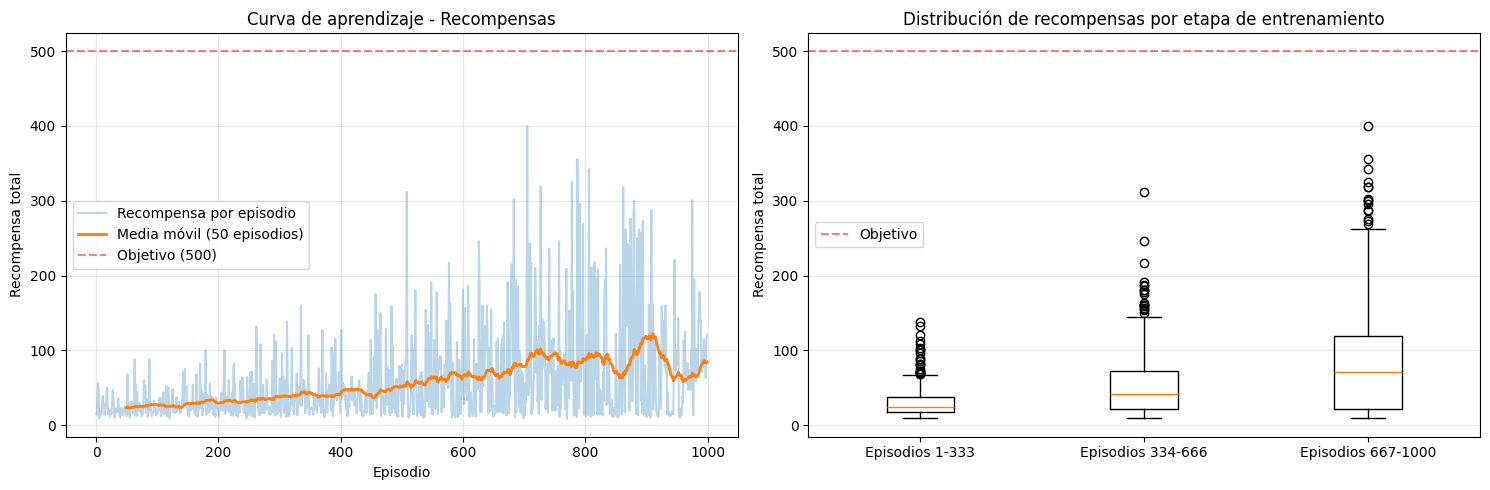


Estadísticas de entrenamiento:
  Recompensa promedio (últimos 100 episodios): 74.84
  Recompensa máxima alcanzada: 400.00
  Recompensa mínima: 9.00
  Desviación estándar (últimos 100): 58.53


In [81]:
# Calcular promedios móviles para suavizar las curvas
window_size = 50
rewards_moving_avg = np.convolve(rewards_base, np.ones(window_size)/window_size, mode='valid')

# Graficar resultados
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Recompensas por episodio
axes[0].plot(rewards_base, alpha=0.3, label='Recompensa por episodio')
axes[0].plot(range(window_size-1, len(rewards_base)), rewards_moving_avg, 
             linewidth=2, label=f'Media móvil ({window_size} episodios)')
axes[0].axhline(y=500, color='r', linestyle='--', alpha=0.5, label='Objetivo (500)')
axes[0].set_xlabel('Episodio')
axes[0].set_ylabel('Recompensa total')
axes[0].set_title('Curva de aprendizaje - Recompensas')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución de recompensas en diferentes etapas
early_rewards = rewards_base[:n_episodes_base//3]
mid_rewards = rewards_base[n_episodes_base//3:2*n_episodes_base//3]
late_rewards = rewards_base[2*n_episodes_base//3:]

axes[1].boxplot([early_rewards, mid_rewards, late_rewards], 
                labels=['Episodios 1-333', 'Episodios 334-666', 'Episodios 667-1000'])
axes[1].axhline(y=500, color='r', linestyle='--', alpha=0.5, label='Objetivo')
axes[1].set_ylabel('Recompensa total')
axes[1].set_title('Distribución de recompensas por etapa de entrenamiento')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Estadísticas finales
print("\nEstadísticas de entrenamiento:")
print(f"  Recompensa promedio (últimos 100 episodios): {np.mean(rewards_base[-100:]):.2f}")
print(f"  Recompensa máxima alcanzada: {np.max(rewards_base):.2f}")
print(f"  Recompensa mínima: {np.min(rewards_base):.2f}")
print(f"  Desviación estándar (últimos 100): {np.std(rewards_base[-100:]):.2f}")

## Evaluación del agente entrenado

Se evalúa el desempeño del agente entrenado ejecutando episodios sin exploración (política greedy pura).

In [82]:
def evaluate_agent(env, Q_table, discretize_fn, n_episodes=100):
    """
    Evalúa el desempeño de un agente entrenado.
    
    Args:
        env: Entorno de Gymnasium
        Q_table: Tabla Q del agente entrenado
        discretize_fn: Función para discretizar observaciones
        n_episodes: Número de episodios de evaluación
    
    Returns:
        eval_rewards: Lista de recompensas obtenidas
        eval_steps: Lista de pasos por episodio
    """
    eval_rewards = []
    eval_steps = []
    
    for episode in range(n_episodes):
        obs, _ = env.reset()
        state = discretize_fn(obs)
        total_reward = 0
        steps = 0
        done = False
        
        while not done:
            # Usar política greedy (sin exploración)
            action = greedy_policy(state, Q_table)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            state = discretize_fn(obs)
            
            total_reward += reward
            steps += 1
        
        eval_rewards.append(total_reward)
        eval_steps.append(steps)
    
    return eval_rewards, eval_steps

Evaluando agente entrenado...

Resultados de evaluación (100 episodios sin exploración):
  Recompensa promedio: 129.33 ± 53.07
  Recompensa mediana: 122.50
  Recompensa máxima: 404.00
  Recompensa mínima: 36.00
  Episodios exitosos (>= 500): 0/100

Resultados de evaluación (100 episodios sin exploración):
  Recompensa promedio: 129.33 ± 53.07
  Recompensa mediana: 122.50
  Recompensa máxima: 404.00
  Recompensa mínima: 36.00
  Episodios exitosos (>= 500): 0/100


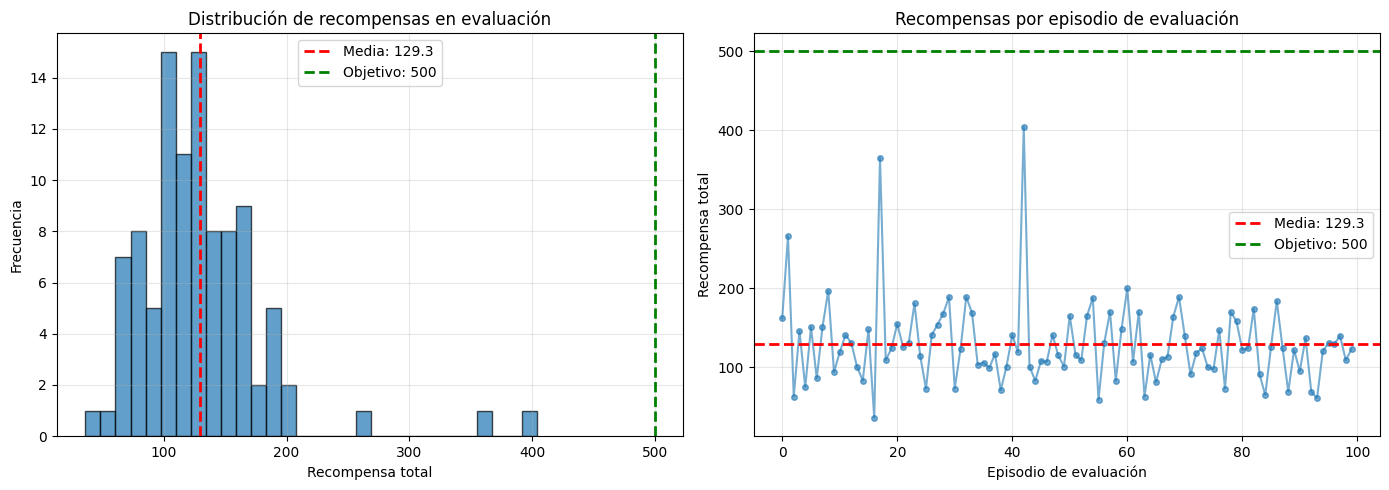

In [83]:
# Evaluar el agente entrenado
print("Evaluando agente entrenado...")
eval_rewards, eval_steps = evaluate_agent(env, Q_table_coarse, discretize_observation_coarse, n_episodes=100)

print("\nResultados de evaluación (100 episodios sin exploración):")
print(f"  Recompensa promedio: {np.mean(eval_rewards):.2f} ± {np.std(eval_rewards):.2f}")
print(f"  Recompensa mediana: {np.median(eval_rewards):.2f}")
print(f"  Recompensa máxima: {np.max(eval_rewards):.2f}")
print(f"  Recompensa mínima: {np.min(eval_rewards):.2f}")
print(f"  Episodios exitosos (>= 500): {sum(r >= 500 for r in eval_rewards)}/100")

# Visualizar resultados de evaluación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(eval_rewards, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(eval_rewards), color='r', linestyle='--', linewidth=2, label=f'Media: {np.mean(eval_rewards):.1f}')
axes[0].axvline(500, color='g', linestyle='--', linewidth=2, label='Objetivo: 500')
axes[0].set_xlabel('Recompensa total')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de recompensas en evaluación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(eval_rewards, marker='o', linestyle='-', alpha=0.6, markersize=4)
axes[1].axhline(np.mean(eval_rewards), color='r', linestyle='--', linewidth=2, label=f'Media: {np.mean(eval_rewards):.1f}')
axes[1].axhline(500, color='g', linestyle='--', linewidth=2, label='Objetivo: 500')
axes[1].set_xlabel('Episodio de evaluación')
axes[1].set_ylabel('Recompensa total')
axes[1].set_title('Recompensas por episodio de evaluación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Exploración de Hiperparámetros

Los resultados iniciales muestran que el agente aprende pero no alcanza el desempeño esperado. En esta sección se realiza una búsqueda sistemática de hiperparámetros para optimizar el rendimiento del algoritmo con discretización gruesa.

## Definición del espacio de búsqueda

Se explorarán los siguientes hiperparámetros:
- **Alpha (α)**: Tasa de aprendizaje que controla cuánto se actualizan los valores Q
- **Gamma (γ)**: Factor de descuento que determina la importancia de recompensas futuras
- **Epsilon final**: Valor mínimo de exploración al finalizar el entrenamiento
- **Número de episodios**: Duración del entrenamiento
- **Tipo de decaimiento**: Estrategia para reducir epsilon durante el entrenamiento

In [84]:
# Definir grid exhaustivo de hiperparámetros a explorar
hyperparameter_grid = {
    'alpha': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    'gamma': [0.90, 0.95, 0.99],
    'epsilon_end': [0.01, 0.05, 0.1],
    'epsilon_decay': ['linear', 'exponential']
}

# Para discretización gruesa (324 estados), usar suficientes episodios
n_episodes_coarse = 8000

print("Espacio de hiperparámetros para búsqueda exhaustiva:")
for param, values in hyperparameter_grid.items():
    print(f"  {param}: {values}")

print(f"\nNúmero de episodios por experimento: {n_episodes_coarse}")

# Calcular número total de combinaciones
import itertools
total_combinations = 1
for values in hyperparameter_grid.values():
    total_combinations *= len(values)

print(f"\nTotal de combinaciones: {total_combinations}")
print(f"Se ejecutarán TODAS las combinaciones para una exploración exhaustiva.")
print(f"Tiempo estimado: ~{total_combinations * n_episodes_coarse / 1000 * 0.0012:.1f} minutos")

Espacio de hiperparámetros para búsqueda exhaustiva:
  alpha: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
  gamma: [0.9, 0.95, 0.99]
  epsilon_end: [0.01, 0.05, 0.1]
  epsilon_decay: ['linear', 'exponential']

Número de episodios por experimento: 8000

Total de combinaciones: 108
Se ejecutarán TODAS las combinaciones para una exploración exhaustiva.
Tiempo estimado: ~1.0 minutos


## Grid Search exhaustivo

Se realizará una búsqueda exhaustiva probando todas las combinaciones del espacio de hiperparámetros. Esta estrategia garantiza encontrar la configuración óptima dentro del espacio definido.

In [85]:
# Generar todas las combinaciones de hiperparámetros
from itertools import product

all_combinations = list(product(
    hyperparameter_grid['alpha'],
    hyperparameter_grid['gamma'],
    hyperparameter_grid['epsilon_end'],
    hyperparameter_grid['epsilon_decay']
))

experiments = []
for i, (alpha, gamma, eps_end, decay) in enumerate(all_combinations, 1):
    experiments.append({
        'id': i,
        'alpha': alpha,
        'gamma': gamma,
        'epsilon_end': eps_end,
        'n_episodes': n_episodes_coarse,
        'epsilon_decay': decay
    })

print(f"Total de experimentos a ejecutar: {len(experiments)}")
print("\nPrimeros 5 experimentos como muestra:")
for exp in experiments[:5]:
    print(f"  Exp {exp['id']}: α={exp['alpha']}, γ={exp['gamma']}, "
          f"ε_end={exp['epsilon_end']}, decay={exp['epsilon_decay']}")
print("  ...")

Total de experimentos a ejecutar: 108

Primeros 5 experimentos como muestra:
  Exp 1: α=0.1, γ=0.9, ε_end=0.01, decay=linear
  Exp 2: α=0.1, γ=0.9, ε_end=0.01, decay=exponential
  Exp 3: α=0.1, γ=0.9, ε_end=0.05, decay=linear
  Exp 4: α=0.1, γ=0.9, ε_end=0.05, decay=exponential
  Exp 5: α=0.1, γ=0.9, ε_end=0.1, decay=linear
  ...


In [86]:
# Ejecutar grid search exhaustivo
results = []
start_total = time.time()

for i, exp in enumerate(experiments, 1):
    print(f"Experimento {i}/{len(experiments)} | α={exp['alpha']}, γ={exp['gamma']}, "
          f"ε_end={exp['epsilon_end']}, decay={exp['epsilon_decay']}", end=" ")
    
    # Inicializar nueva tabla Q para cada experimento
    Q_table_exp = np.zeros((
        n_bins_cart_pos_coarse,
        n_bins_cart_vel_coarse,
        n_bins_pole_angle_coarse,
        n_bins_pole_ang_vel_coarse,
        env.action_space.n
    ))
    
    # Entrenar (sin prints intermedios para no saturar output)
    start_time = time.time()
    rewards_history, steps_history = q_learning_train(
        env=env,
        Q_table=Q_table_exp,
        discretize_fn=discretize_observation_coarse,
        n_episodes=exp['n_episodes'],
        alpha=exp['alpha'],
        gamma=exp['gamma'],
        epsilon_start=1.0,
        epsilon_end=exp['epsilon_end'],
        epsilon_decay_type=exp['epsilon_decay']
    )
    training_time = time.time() - start_time
    
    # Evaluar
    eval_rewards, eval_steps = evaluate_agent(env, Q_table_exp, discretize_observation_coarse, n_episodes=100)
    
    # Guardar resultados
    result = {
        'id': exp['id'],
        'params': exp,
        'training_avg_last_100': np.mean(rewards_history[-100:]),
        'training_max': np.max(rewards_history),
        'training_std_last_100': np.std(rewards_history[-100:]),
        'eval_mean': np.mean(eval_rewards),
        'eval_std': np.std(eval_rewards),
        'eval_median': np.median(eval_rewards),
        'eval_max': np.max(eval_rewards),
        'eval_min': np.min(eval_rewards),
        'success_rate': sum(r >= 500 for r in eval_rewards) / len(eval_rewards),
        'training_time': training_time,
        'rewards_history': rewards_history,
        'eval_rewards': eval_rewards,
        'Q_table': Q_table_exp
    }
    results.append(result)
    
    print(f"→ Eval: {result['eval_mean']:.1f}±{result['eval_std']:.1f} | {training_time:.1f}s")
    
    # Mostrar progreso cada 10 experimentos
    if i % 10 == 0:
        elapsed = time.time() - start_total
        avg_time = elapsed / i
        remaining = avg_time * (len(experiments) - i)
        print(f"  Progreso: {i}/{len(experiments)} ({i/len(experiments)*100:.1f}%) | "
              f"Tiempo restante estimado: {remaining/60:.1f} min")

total_time = time.time() - start_total
print(f"\n{'='*70}")
print(f"Grid search completado en {total_time/60:.2f} minutos")
print(f"{'='*70}")

Experimento 1/108 | α=0.1, γ=0.9, ε_end=0.01, decay=linear Episodio 100/8000, Epsilon: 0.988, Recompensa promedio (últimos 100): 21.62
Episodio 200/8000, Epsilon: 0.975, Recompensa promedio (últimos 100): 22.70
Episodio 300/8000, Epsilon: 0.963, Recompensa promedio (últimos 100): 22.56
Episodio 400/8000, Epsilon: 0.951, Recompensa promedio (últimos 100): 23.17
Episodio 500/8000, Epsilon: 0.938, Recompensa promedio (últimos 100): 23.55
Episodio 600/8000, Epsilon: 0.926, Recompensa promedio (últimos 100): 23.37
Episodio 700/8000, Epsilon: 0.913, Recompensa promedio (últimos 100): 24.21
Episodio 800/8000, Epsilon: 0.901, Recompensa promedio (últimos 100): 24.33
Episodio 900/8000, Epsilon: 0.889, Recompensa promedio (últimos 100): 24.53
Episodio 1000/8000, Epsilon: 0.876, Recompensa promedio (últimos 100): 25.72
Episodio 1100/8000, Epsilon: 0.864, Recompensa promedio (últimos 100): 26.62
Episodio 1200/8000, Epsilon: 0.852, Recompensa promedio (últimos 100): 26.98
Episodio 1300/8000, Epsilo

## Análisis comparativo de resultados

In [87]:
# Crear tabla comparativa completa
import pandas as pd

comparison_data = []
for result in results:
    comparison_data.append({
        'ID': result['id'],
        'Alpha': result['params']['alpha'],
        'Gamma': result['params']['gamma'],
        'Eps_end': result['params']['epsilon_end'],
        'Decay': result['params']['epsilon_decay'],
        'Eval_Mean': result['eval_mean'],
        'Eval_Std': result['eval_std'],
        'Eval_Max': result['eval_max'],
        'Success_%': result['success_rate'] * 100,
        'Train_Time_s': result['training_time']
    })

df_results = pd.DataFrame(comparison_data)

# Ordenar por rendimiento en evaluación (descendente)
df_results_sorted = df_results.sort_values('Eval_Mean', ascending=False)

print("Top 10 mejores configuraciones:")
print("="*120)
print(df_results_sorted.head(10).to_string(index=False))
print("="*120)

print("\nTop 10 peores configuraciones:")
print("="*120)
print(df_results_sorted.tail(10).to_string(index=False))
print("="*120)

# Identificar mejor configuración
best_idx = df_results_sorted.index[0]
best_result = results[best_idx]

print(f"\nMejor configuración encontrada (ID: {best_result['id']}):")
print(f"  α = {best_result['params']['alpha']}")
print(f"  γ = {best_result['params']['gamma']}")
print(f"  ε_final = {best_result['params']['epsilon_end']}")
print(f"  Decaimiento = {best_result['params']['epsilon_decay']}")
print(f"\nRendimiento:")
print(f"  Recompensa promedio: {best_result['eval_mean']:.2f} ± {best_result['eval_std']:.2f}")
print(f"  Recompensa mediana: {best_result['eval_median']:.2f}")
print(f"  Recompensa máxima: {best_result['eval_max']:.2f}")
print(f"  Tasa de éxito (>=500): {best_result['success_rate']*100:.1f}%")

# Guardar tabla completa para análisis posterior
df_results_sorted.to_csv('hyperparameter_search_coarse.csv', index=False)
print("\nTabla completa guardada en: hyperparameter_search_coarse.csv")

Top 10 mejores configuraciones:
 ID  Alpha  Gamma  Eps_end       Decay  Eval_Mean  Eval_Std  Eval_Max  Success_%  Train_Time_s
106    0.6   0.99     0.05 exponential      83.18 69.531630     225.0        0.0      3.795146
 35    0.2   0.99     0.10      linear      40.92 46.927323     206.0        0.0      4.259888
 23    0.2   0.90     0.10      linear      36.20 40.501852     146.0        0.0      4.285045
 17    0.1   0.99     0.10      linear      13.82  3.287491      25.0        0.0      4.669734
103    0.6   0.99     0.01      linear      13.57  3.147237      23.0        0.0      4.073216
 44    0.3   0.95     0.01 exponential      13.24  2.832384      23.0        0.0      3.329403
 27    0.2   0.95     0.05      linear      12.37  3.214514      25.0        0.0      4.844897
 76    0.5   0.90     0.05 exponential      12.20  2.634388      22.0        0.0      3.988019
104    0.6   0.99     0.01 exponential      12.12  1.243222      14.0        0.0      3.904515
 50    0.3   0.99 

In [88]:
# Análisis estadístico del impacto de hiperparámetros
print("\nAnálisis del impacto de cada hiperparámetro:\n")

# Agrupar por alpha
print("Impacto de Alpha:")
for alpha_val in sorted(hyperparameter_grid['alpha']):
    alpha_results = [r for r in results if r['params']['alpha'] == alpha_val]
    avg_perf = np.mean([r['eval_mean'] for r in alpha_results])
    std_perf = np.std([r['eval_mean'] for r in alpha_results])
    print(f"  α={alpha_val}: {avg_perf:.2f} ± {std_perf:.2f}")

# Agrupar por gamma
print("\nImpacto de Gamma:")
for gamma_val in sorted(hyperparameter_grid['gamma']):
    gamma_results = [r for r in results if r['params']['gamma'] == gamma_val]
    avg_perf = np.mean([r['eval_mean'] for r in gamma_results])
    std_perf = np.std([r['eval_mean'] for r in gamma_results])
    print(f"  γ={gamma_val}: {avg_perf:.2f} ± {std_perf:.2f}")

# Agrupar por epsilon_end
print("\nImpacto de Epsilon final:")
for eps_val in sorted(hyperparameter_grid['epsilon_end']):
    eps_results = [r for r in results if r['params']['epsilon_end'] == eps_val]
    avg_perf = np.mean([r['eval_mean'] for r in eps_results])
    std_perf = np.std([r['eval_mean'] for r in eps_results])
    print(f"  ε_end={eps_val}: {avg_perf:.2f} ± {std_perf:.2f}")

# Agrupar por decay
print("\nImpacto de Tipo de decaimiento:")
for decay_val in hyperparameter_grid['epsilon_decay']:
    decay_results = [r for r in results if r['params']['epsilon_decay'] == decay_val]
    avg_perf = np.mean([r['eval_mean'] for r in decay_results])
    std_perf = np.std([r['eval_mean'] for r in decay_results])
    print(f"  {decay_val}: {avg_perf:.2f} ± {std_perf:.2f}")


Análisis del impacto de cada hiperparámetro:

Impacto de Alpha:
  α=0.1: 10.83 ± 0.95
  α=0.2: 14.11 ± 8.71
  α=0.3: 10.96 ± 0.91
  α=0.4: 10.78 ± 0.79
  α=0.5: 10.59 ± 0.81
  α=0.6: 14.71 ± 16.64

Impacto de Gamma:
  γ=0.9: 11.21 ± 4.28
  γ=0.95: 10.68 ± 0.86
  γ=0.99: 14.09 ± 12.69

Impacto de Epsilon final:
  ε_end=0.01: 10.73 ± 1.04
  ε_end=0.05: 12.72 ± 11.93
  ε_end=0.1: 12.53 ± 6.40

Impacto de Tipo de decaimiento:
  linear: 11.78 ± 5.36
  exponential: 12.21 ± 9.78


# Q-Learning con Discretización Fina

Los resultados de la discretización gruesa demostraron que 324 estados son insuficientes para resolver CartPole-v1, incluso con optimización exhaustiva de hiperparámetros. En esta sección se implementa Q-Learning con discretización fina (5,184 estados) para capturar la complejidad necesaria del problema.

## Inicialización de la tabla Q fina

Se inicializa la tabla Q para la discretización fina con 5,184 estados (16 veces más que la gruesa).

In [91]:
# Inicializar tabla Q para discretización fina
# Dimensiones: (cart_pos, cart_vel, pole_angle, pole_ang_vel, acciones)
Q_table_fine = np.zeros((
    n_bins_cart_pos_fine,
    n_bins_cart_vel_fine,
    n_bins_pole_angle_fine,
    n_bins_pole_ang_vel_fine,
    env.action_space.n
))

print(f"Tabla Q fina inicializada con forma: {Q_table_fine.shape}")
print(f"Total de valores en la tabla Q: {Q_table_fine.size}")
print(f"Memoria utilizada: {Q_table_fine.nbytes / 1024:.2f} KB")
print(f"\nComparación con discretización gruesa:")
print(f"  Gruesa: {Q_table_coarse.size} valores ({Q_table_coarse.nbytes / 1024:.2f} KB)")
print(f"  Fina: {Q_table_fine.size} valores ({Q_table_fine.nbytes / 1024:.2f} KB)")
print(f"  Ratio: {Q_table_fine.size / Q_table_coarse.size:.1f}x más grande")

Tabla Q fina inicializada con forma: (6, 6, 12, 12, 2)
Total de valores en la tabla Q: 10368
Memoria utilizada: 81.00 KB

Comparación con discretización gruesa:
  Gruesa: 648 valores (5.06 KB)
  Fina: 10368 valores (81.00 KB)
  Ratio: 16.0x más grande


## Configuración del Grid Search para discretización fina

Basándose en los resultados de la discretización gruesa, se define un espacio de búsqueda optimizado:
- Se eliminan valores de gamma que demostraron bajo rendimiento (0.90)
- Se mantienen los mismos rangos de alpha y epsilon_end que mostraron buenos resultados
- Se incrementa el número de episodios para dar tiempo suficiente de exploración al espacio 16x más grande

In [92]:
# Definir grid optimizado de hiperparámetros para discretización fina
hyperparameter_grid_fine = {
    'alpha': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    'gamma': [0.95, 0.99],  # Eliminando 0.90 que tuvo bajo rendimiento en gruesa
    'epsilon_end': [0.01, 0.05, 0.1],
    'epsilon_decay': ['linear', 'exponential']
}

# Para discretización fina (5,184 estados), usar más episodios que gruesa
n_episodes_fine = 15000
n_eval_episodes_fine = 200  # Más episodios de evaluación para mayor robustez

print("Espacio de hiperparámetros para discretización fina:")
for param, values in hyperparameter_grid_fine.items():
    print(f"  {param}: {values}")

print(f"\nNúmero de episodios de entrenamiento por experimento: {n_episodes_fine}")
print(f"Número de episodios de evaluación por experimento: {n_eval_episodes_fine}")

# Calcular número total de combinaciones
total_combinations_fine = 1
for values in hyperparameter_grid_fine.values():
    total_combinations_fine *= len(values)

print(f"\nTotal de experimentos: {total_combinations_fine}")
print(f"  6 alphas × 2 gammas × 3 epsilon_end × 2 decay = {total_combinations_fine} combinaciones")
print(f"\nTiempo estimado: ~{total_combinations_fine * n_episodes_fine / 1000 * 0.0015:.1f} minutos")
print(f"  ({total_combinations_fine * n_episodes_fine / 1000 * 0.0015 / 60:.1f} horas)")

Espacio de hiperparámetros para discretización fina:
  alpha: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
  gamma: [0.95, 0.99]
  epsilon_end: [0.01, 0.05, 0.1]
  epsilon_decay: ['linear', 'exponential']

Número de episodios de entrenamiento por experimento: 15000
Número de episodios de evaluación por experimento: 200

Total de experimentos: 72
  6 alphas × 2 gammas × 3 epsilon_end × 2 decay = 72 combinaciones

Tiempo estimado: ~1.6 minutos
  (0.0 horas)


## Generación de experimentos

In [93]:
# Generar todas las combinaciones de hiperparámetros para discretización fina
all_combinations_fine = list(product(
    hyperparameter_grid_fine['alpha'],
    hyperparameter_grid_fine['gamma'],
    hyperparameter_grid_fine['epsilon_end'],
    hyperparameter_grid_fine['epsilon_decay']
))

experiments_fine = []
for i, (alpha, gamma, eps_end, decay) in enumerate(all_combinations_fine, 1):
    experiments_fine.append({
        'id': i,
        'alpha': alpha,
        'gamma': gamma,
        'epsilon_end': eps_end,
        'n_episodes': n_episodes_fine,
        'epsilon_decay': decay
    })

print(f"Total de experimentos a ejecutar: {len(experiments_fine)}")
print("\nPrimeros 10 experimentos:")
for exp in experiments_fine[:10]:
    print(f"  Exp {exp['id']:2d}: α={exp['alpha']}, γ={exp['gamma']}, "
          f"ε_end={exp['epsilon_end']}, decay={exp['epsilon_decay']}")
print("  ...")
print(f"\nÚltimos 3 experimentos:")
for exp in experiments_fine[-3:]:
    print(f"  Exp {exp['id']:2d}: α={exp['alpha']}, γ={exp['gamma']}, "
          f"ε_end={exp['epsilon_end']}, decay={exp['epsilon_decay']}")

Total de experimentos a ejecutar: 72

Primeros 10 experimentos:
  Exp  1: α=0.1, γ=0.95, ε_end=0.01, decay=linear
  Exp  2: α=0.1, γ=0.95, ε_end=0.01, decay=exponential
  Exp  3: α=0.1, γ=0.95, ε_end=0.05, decay=linear
  Exp  4: α=0.1, γ=0.95, ε_end=0.05, decay=exponential
  Exp  5: α=0.1, γ=0.95, ε_end=0.1, decay=linear
  Exp  6: α=0.1, γ=0.95, ε_end=0.1, decay=exponential
  Exp  7: α=0.1, γ=0.99, ε_end=0.01, decay=linear
  Exp  8: α=0.1, γ=0.99, ε_end=0.01, decay=exponential
  Exp  9: α=0.1, γ=0.99, ε_end=0.05, decay=linear
  Exp 10: α=0.1, γ=0.99, ε_end=0.05, decay=exponential
  ...

Últimos 3 experimentos:
  Exp 70: α=0.6, γ=0.99, ε_end=0.05, decay=exponential
  Exp 71: α=0.6, γ=0.99, ε_end=0.1, decay=linear
  Exp 72: α=0.6, γ=0.99, ε_end=0.1, decay=exponential


## Ejecución del Grid Search

Se ejecutarán los 72 experimentos con discretización fina. Cada experimento:
1. Inicializa una nueva tabla Q vacía
2. Entrena durante 15,000 episodios
3. Evalúa el rendimiento durante 200 episodios sin exploración
4. Guarda todas las métricas para análisis posterior

In [94]:
# Ejecutar grid search con discretización fina
results_fine = []
start_total_fine = time.time()

print("Iniciando grid search con discretización fina...")
print(f"{'='*70}\n")

for i, exp in enumerate(experiments_fine, 1):
    print(f"Experimento {i}/{len(experiments_fine)} | α={exp['alpha']}, γ={exp['gamma']}, "
          f"ε_end={exp['epsilon_end']}, decay={exp['epsilon_decay']}", end=" ")
    
    # Inicializar nueva tabla Q para cada experimento
    Q_table_exp_fine = np.zeros((
        n_bins_cart_pos_fine,
        n_bins_cart_vel_fine,
        n_bins_pole_angle_fine,
        n_bins_pole_ang_vel_fine,
        env.action_space.n
    ))
    
    # Entrenar (sin prints intermedios para no saturar output)
    start_time = time.time()
    rewards_history, steps_history = q_learning_train(
        env=env,
        Q_table=Q_table_exp_fine,
        discretize_fn=discretize_observation_fine,
        n_episodes=exp['n_episodes'],
        alpha=exp['alpha'],
        gamma=exp['gamma'],
        epsilon_start=1.0,
        epsilon_end=exp['epsilon_end'],
        epsilon_decay_type=exp['epsilon_decay']
    )
    training_time = time.time() - start_time
    
    # Evaluar con más episodios para mayor robustez
    eval_rewards, eval_steps = evaluate_agent(
        env, 
        Q_table_exp_fine, 
        discretize_observation_fine, 
        n_episodes=n_eval_episodes_fine
    )
    
    # Guardar resultados
    result = {
        'id': exp['id'],
        'params': exp,
        'training_avg_last_100': np.mean(rewards_history[-100:]),
        'training_max': np.max(rewards_history),
        'training_std_last_100': np.std(rewards_history[-100:]),
        'eval_mean': np.mean(eval_rewards),
        'eval_std': np.std(eval_rewards),
        'eval_median': np.median(eval_rewards),
        'eval_max': np.max(eval_rewards),
        'eval_min': np.min(eval_rewards),
        'success_rate': sum(r >= 500 for r in eval_rewards) / len(eval_rewards),
        'training_time': training_time,
        'rewards_history': rewards_history,
        'eval_rewards': eval_rewards,
        'Q_table': Q_table_exp_fine
    }
    results_fine.append(result)
    
    print(f"→ Eval: {result['eval_mean']:.1f}±{result['eval_std']:.1f} | "
          f"Success: {result['success_rate']*100:.0f}% | {training_time:.1f}s")
    
    # Mostrar progreso cada 10 experimentos
    if i % 10 == 0:
        elapsed = time.time() - start_total_fine
        avg_time = elapsed / i
        remaining = avg_time * (len(experiments_fine) - i)
        print(f"  Progreso: {i}/{len(experiments_fine)} ({i/len(experiments_fine)*100:.1f}%) | "
              f"Tiempo restante estimado: {remaining/60:.1f} min")
        print()

total_time_fine = time.time() - start_total_fine
print(f"\n{'='*70}")
print(f"Grid search con discretización fina completado en {total_time_fine/60:.2f} minutos")
print(f"{'='*70}")

Iniciando grid search con discretización fina...

Experimento 1/72 | α=0.1, γ=0.95, ε_end=0.01, decay=linear Episodio 100/15000, Epsilon: 0.993, Recompensa promedio (últimos 100): 23.32
Episodio 200/15000, Epsilon: 0.987, Recompensa promedio (últimos 100): 23.51
Episodio 300/15000, Epsilon: 0.980, Recompensa promedio (últimos 100): 21.53
Episodio 400/15000, Epsilon: 0.974, Recompensa promedio (últimos 100): 23.47
Episodio 500/15000, Epsilon: 0.967, Recompensa promedio (últimos 100): 24.16
Episodio 600/15000, Epsilon: 0.960, Recompensa promedio (últimos 100): 23.35
Episodio 700/15000, Epsilon: 0.954, Recompensa promedio (últimos 100): 22.19
Episodio 800/15000, Epsilon: 0.947, Recompensa promedio (últimos 100): 24.12
Episodio 900/15000, Epsilon: 0.941, Recompensa promedio (últimos 100): 24.70
Episodio 1000/15000, Epsilon: 0.934, Recompensa promedio (últimos 100): 21.42
Episodio 1100/15000, Epsilon: 0.927, Recompensa promedio (últimos 100): 21.97
Episodio 1200/15000, Epsilon: 0.921, Recom

## Análisis de resultados - Discretización fina

In [95]:
# Crear tabla comparativa completa para discretización fina
comparison_data_fine = []
for result in results_fine:
    comparison_data_fine.append({
        'ID': result['id'],
        'Alpha': result['params']['alpha'],
        'Gamma': result['params']['gamma'],
        'Eps_end': result['params']['epsilon_end'],
        'Decay': result['params']['epsilon_decay'],
        'Eval_Mean': result['eval_mean'],
        'Eval_Std': result['eval_std'],
        'Eval_Max': result['eval_max'],
        'Success_%': result['success_rate'] * 100,
        'Train_Time_s': result['training_time']
    })

df_results_fine = pd.DataFrame(comparison_data_fine)

# Ordenar por rendimiento en evaluación (descendente)
df_results_fine_sorted = df_results_fine.sort_values('Eval_Mean', ascending=False)

print("Top 15 mejores configuraciones (Discretización Fina):")
print("="*120)
print(df_results_fine_sorted.head(15).to_string(index=False))
print("="*120)

print("\nTop 10 peores configuraciones (Discretización Fina):")
print("="*120)
print(df_results_fine_sorted.tail(10).to_string(index=False))
print("="*120)

# Identificar mejor configuración
best_idx_fine = df_results_fine_sorted.index[0]
best_result_fine = results_fine[best_idx_fine]

print(f"\n{'='*70}")
print(f"MEJOR CONFIGURACIÓN ENCONTRADA (Discretización Fina - ID: {best_result_fine['id']})")
print(f"{'='*70}")
print(f"\nHiperparámetros:")
print(f"  α (alpha) = {best_result_fine['params']['alpha']}")
print(f"  γ (gamma) = {best_result_fine['params']['gamma']}")
print(f"  ε_final (epsilon_end) = {best_result_fine['params']['epsilon_end']}")
print(f"  Decaimiento = {best_result_fine['params']['epsilon_decay']}")
print(f"  Episodios de entrenamiento = {best_result_fine['params']['n_episodes']}")
print(f"\nRendimiento en evaluación ({n_eval_episodes_fine} episodios):")
print(f"  Recompensa promedio: {best_result_fine['eval_mean']:.2f} ± {best_result_fine['eval_std']:.2f}")
print(f"  Recompensa mediana: {best_result_fine['eval_median']:.2f}")
print(f"  Recompensa máxima: {best_result_fine['eval_max']:.2f}")
print(f"  Recompensa mínima: {best_result_fine['eval_min']:.2f}")
print(f"  Tasa de éxito (>=500): {best_result_fine['success_rate']*100:.1f}%")
print(f"  Episodios exitosos: {int(best_result_fine['success_rate']*n_eval_episodes_fine)}/{n_eval_episodes_fine}")
print(f"\nTiempo de entrenamiento: {best_result_fine['training_time']:.1f} segundos ({best_result_fine['training_time']/60:.2f} minutos)")
print(f"{'='*70}")

# Guardar tabla completa para análisis posterior
df_results_fine_sorted.to_csv('hyperparameter_search_fine.csv', index=False)
print("\nTabla completa guardada en: hyperparameter_search_fine.csv")

Top 15 mejores configuraciones (Discretización Fina):
 ID  Alpha  Gamma  Eps_end       Decay  Eval_Mean   Eval_Std  Eval_Max  Success_%  Train_Time_s
  8    0.1   0.99     0.01 exponential    500.000   0.000000     500.0      100.0     90.748539
  7    0.1   0.99     0.01      linear    496.665  28.025217     500.0       98.5     42.564888
  9    0.1   0.99     0.05      linear    453.495  71.515033     500.0       63.5     39.088414
 32    0.3   0.99     0.01 exponential    340.690 160.955689     500.0       40.0     53.232627
 10    0.1   0.99     0.05 exponential    284.050  58.420609     500.0        3.5     57.510043
 20    0.2   0.99     0.01 exponential    248.360 102.061356     470.0        0.0    104.962757
 22    0.2   0.99     0.05 exponential    236.935  76.482879     500.0        2.5     50.670573
 24    0.2   0.99     0.10 exponential    224.540  96.019573     500.0        3.5     46.021999
 11    0.1   0.99     0.10      linear    224.015  66.954423     500.0        1.0 

In [96]:
# Análisis estadístico del impacto de hiperparámetros en discretización fina
print("Análisis del impacto de cada hiperparámetro (Discretización Fina):\n")

# Agrupar por alpha
print("Impacto de Alpha (α):")
for alpha_val in sorted(hyperparameter_grid_fine['alpha']):
    alpha_results = [r for r in results_fine if r['params']['alpha'] == alpha_val]
    avg_perf = np.mean([r['eval_mean'] for r in alpha_results])
    std_perf = np.std([r['eval_mean'] for r in alpha_results])
    avg_success = np.mean([r['success_rate'] for r in alpha_results]) * 100
    print(f"  α={alpha_val}: {avg_perf:.2f} ± {std_perf:.2f} | Success: {avg_success:.1f}%")

# Agrupar por gamma
print("\nImpacto de Gamma (γ):")
for gamma_val in sorted(hyperparameter_grid_fine['gamma']):
    gamma_results = [r for r in results_fine if r['params']['gamma'] == gamma_val]
    avg_perf = np.mean([r['eval_mean'] for r in gamma_results])
    std_perf = np.std([r['eval_mean'] for r in gamma_results])
    avg_success = np.mean([r['success_rate'] for r in gamma_results]) * 100
    print(f"  γ={gamma_val}: {avg_perf:.2f} ± {std_perf:.2f} | Success: {avg_success:.1f}%")

# Agrupar por epsilon_end
print("\nImpacto de Epsilon final (ε_end):")
for eps_val in sorted(hyperparameter_grid_fine['epsilon_end']):
    eps_results = [r for r in results_fine if r['params']['epsilon_end'] == eps_val]
    avg_perf = np.mean([r['eval_mean'] for r in eps_results])
    std_perf = np.std([r['eval_mean'] for r in eps_results])
    avg_success = np.mean([r['success_rate'] for r in eps_results]) * 100
    print(f"  ε_end={eps_val}: {avg_perf:.2f} ± {std_perf:.2f} | Success: {avg_success:.1f}%")

# Agrupar por decay
print("\nImpacto de Tipo de decaimiento:")
for decay_val in hyperparameter_grid_fine['epsilon_decay']:
    decay_results = [r for r in results_fine if r['params']['epsilon_decay'] == decay_val]
    avg_perf = np.mean([r['eval_mean'] for r in decay_results])
    std_perf = np.std([r['eval_mean'] for r in decay_results])
    avg_success = np.mean([r['success_rate'] for r in decay_results]) * 100
    print(f"  {decay_val}: {avg_perf:.2f} ± {std_perf:.2f} | Success: {avg_success:.1f}%")

# Estadísticas generales
print(f"\n{'='*70}")
print("Estadísticas generales de todos los experimentos con discretización fina:")
print(f"{'='*70}")
all_eval_means = [r['eval_mean'] for r in results_fine]
all_success_rates = [r['success_rate'] for r in results_fine]
print(f"  Recompensa promedio: {np.mean(all_eval_means):.2f} ± {np.std(all_eval_means):.2f}")
print(f"  Recompensa mediana: {np.median(all_eval_means):.2f}")
print(f"  Recompensa máxima: {np.max(all_eval_means):.2f}")
print(f"  Recompensa mínima: {np.min(all_eval_means):.2f}")
print(f"  Tasa de éxito promedio: {np.mean(all_success_rates)*100:.1f}%")
print(f"  Experimentos con éxito >50%: {sum(1 for r in all_success_rates if r > 0.5)}/{len(results_fine)}")
print(f"{'='*70}")

Análisis del impacto de cada hiperparámetro (Discretización Fina):

Impacto de Alpha (α):
  α=0.1: 190.52 ± 188.92 | Success: 22.6%
  α=0.2: 95.43 ± 91.00 | Success: 0.7%
  α=0.3: 57.91 ± 93.32 | Success: 3.3%
  α=0.4: 26.53 ± 8.09 | Success: 0.0%
  α=0.5: 18.26 ± 2.77 | Success: 0.0%
  α=0.6: 25.90 ± 19.27 | Success: 0.9%

Impacto de Gamma (γ):
  γ=0.95: 21.75 ± 10.70 | Success: 0.1%
  γ=0.99: 116.44 ± 142.78 | Success: 9.0%

Impacto de Epsilon final (ε_end):
  ε_end=0.01: 83.91 ± 146.57 | Success: 9.9%
  ε_end=0.05: 69.34 ± 106.46 | Success: 3.6%
  ε_end=0.1: 54.03 ± 64.89 | Success: 0.2%

Impacto de Tipo de decaimiento:
  linear: 61.20 ± 108.58 | Success: 4.6%
  exponential: 76.98 ± 114.32 | Success: 4.6%

Estadísticas generales de todos los experimentos con discretización fina:
  Recompensa promedio: 69.09 ± 111.76
  Recompensa mediana: 20.72
  Recompensa máxima: 500.00
  Recompensa mínima: 14.21
  Tasa de éxito promedio: 4.6%
  Experimentos con éxito >50%: 3/72


## Visualización de resultados - Discretización fina

C:\Users\fagno\AppData\Local\Temp\ipykernel_8564\3379666794.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot([early, mid, late],


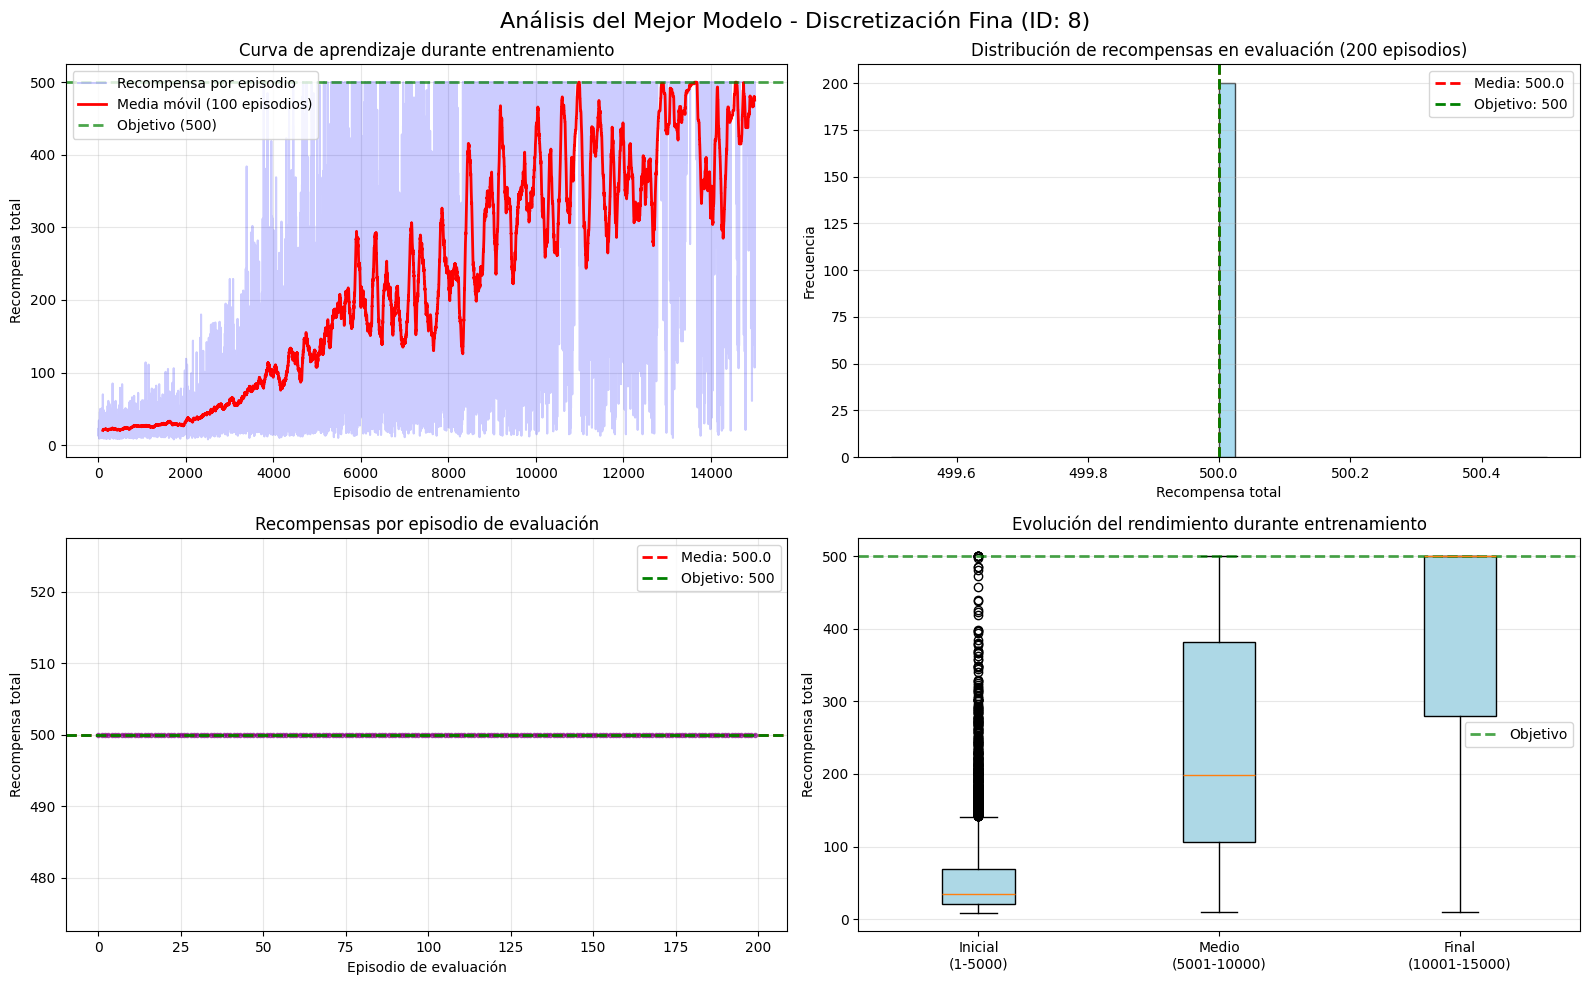


Estadísticas detalladas del mejor modelo:
  Fase de ENTRENAMIENTO (15,000 episodios con exploración):
    - Últimos 100 episodios: 475.29 ± 90.96
    - Recompensa máxima alcanzada: 500.00
    - Episodios perfectos (500): 3937/15000 (26.2%)

  Fase de EVALUACIÓN (200 episodios, política greedy, SIN exploración):
    - Media: 500.00 ± 0.00
    - Episodios perfectos (=500): 200/200 (100.0%)


In [102]:
# Visualizar curva de aprendizaje del mejor modelo
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'Análisis del Mejor Modelo - Discretización Fina (ID: {best_result_fine["id"]})', fontsize=16)

# 1. Curva de aprendizaje durante entrenamiento
window_size = 100
rewards_moving_avg = np.convolve(best_result_fine['rewards_history'], 
                                  np.ones(window_size)/window_size, mode='valid')

axes[0, 0].plot(best_result_fine['rewards_history'], alpha=0.2, label='Recompensa por episodio', color='blue')
axes[0, 0].plot(range(window_size-1, len(best_result_fine['rewards_history'])), 
                rewards_moving_avg, linewidth=2, label=f'Media móvil ({window_size} episodios)', color='red')
axes[0, 0].axhline(y=500, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Objetivo (500)')
axes[0, 0].set_xlabel('Episodio de entrenamiento')
axes[0, 0].set_ylabel('Recompensa total')
axes[0, 0].set_title('Curva de aprendizaje durante entrenamiento')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribución de recompensas en evaluación
axes[0, 1].hist(best_result_fine['eval_rewards'], bins=40, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 1].axvline(best_result_fine['eval_mean'], color='red', linestyle='--', linewidth=2, 
                   label=f'Media: {best_result_fine["eval_mean"]:.1f}')
axes[0, 1].axvline(500, color='green', linestyle='--', linewidth=2, label='Objetivo: 500')
axes[0, 1].set_xlabel('Recompensa total')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title(f'Distribución de recompensas en evaluación ({n_eval_episodes_fine} episodios)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Progresión de recompensas en evaluación
axes[1, 0].plot(best_result_fine['eval_rewards'], marker='o', linestyle='-', 
                alpha=0.6, markersize=3, color='purple')
axes[1, 0].axhline(best_result_fine['eval_mean'], color='red', linestyle='--', 
                   linewidth=2, label=f'Media: {best_result_fine["eval_mean"]:.1f}')
axes[1, 0].axhline(500, color='green', linestyle='--', linewidth=2, label='Objetivo: 500')
axes[1, 0].set_xlabel('Episodio de evaluación')
axes[1, 0].set_ylabel('Recompensa total')
axes[1, 0].set_title('Recompensas por episodio de evaluación')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Comparación de distribuciones por etapa de entrenamiento
n_eps = len(best_result_fine['rewards_history'])
early = best_result_fine['rewards_history'][:n_eps//3]
mid = best_result_fine['rewards_history'][n_eps//3:2*n_eps//3]
late = best_result_fine['rewards_history'][2*n_eps//3:]

bp = axes[1, 1].boxplot([early, mid, late], 
                        labels=[f'Inicial\n(1-{n_eps//3})', 
                               f'Medio\n({n_eps//3+1}-{2*n_eps//3})', 
                               f'Final\n({2*n_eps//3+1}-{n_eps})'],
                        patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1, 1].axhline(y=500, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Objetivo')
axes[1, 1].set_ylabel('Recompensa total')
axes[1, 1].set_title('Evolución del rendimiento durante entrenamiento')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Estadísticas adicionales del mejor modelo
print(f"\nEstadísticas detalladas del mejor modelo:")
print(f"  Fase de ENTRENAMIENTO (15,000 episodios con exploración):")
print(f"    - Últimos 100 episodios: {best_result_fine['training_avg_last_100']:.2f} ± {best_result_fine['training_std_last_100']:.2f}")
print(f"    - Recompensa máxima alcanzada: {best_result_fine['training_max']:.2f}")
print(f"    - Episodios perfectos (500): {sum(1 for r in best_result_fine['rewards_history'] if r >= 500)}/{len(best_result_fine['rewards_history'])} ({100*sum(1 for r in best_result_fine['rewards_history'] if r >= 500)/len(best_result_fine['rewards_history']):.1f}%)")
print(f"\n  Fase de EVALUACIÓN (200 episodios, política greedy, SIN exploración):")
print(f"    - Media: {best_result_fine['eval_mean']:.2f} ± {best_result_fine['eval_std']:.2f}")
print(f"    - Episodios perfectos (=500): {sum(1 for r in best_result_fine['eval_rewards'] if r == 500)}/{n_eval_episodes_fine} ({100*sum(1 for r in best_result_fine['eval_rewards'] if r == 500)/n_eval_episodes_fine:.1f}%)")

## Comparación: Discretización Gruesa vs Fina

Análisis comparativo del rendimiento entre ambas estrategias de discretización.

In [98]:
# Comparación exhaustiva entre discretización gruesa y fina
print("="*80)
print("COMPARACIÓN: DISCRETIZACIÓN GRUESA vs FINA")
print("="*80)

# Mejor resultado de cada discretización
print("\n1. MEJORES CONFIGURACIONES:")
print("-"*80)
print("Discretización GRUESA (324 estados):")
print(f"  Hiperparámetros: α={best_result['params']['alpha']}, γ={best_result['params']['gamma']}, "
      f"ε_end={best_result['params']['epsilon_end']}, decay={best_result['params']['epsilon_decay']}")
print(f"  Recompensa: {best_result['eval_mean']:.2f} ± {best_result['eval_std']:.2f}")
print(f"  Tasa de éxito: {best_result['success_rate']*100:.1f}%")

print("\nDiscretización FINA (5,184 estados):")
print(f"  Hiperparámetros: α={best_result_fine['params']['alpha']}, γ={best_result_fine['params']['gamma']}, "
      f"ε_end={best_result_fine['params']['epsilon_end']}, decay={best_result_fine['params']['epsilon_decay']}")
print(f"  Recompensa: {best_result_fine['eval_mean']:.2f} ± {best_result_fine['eval_std']:.2f}")
print(f"  Tasa de éxito: {best_result_fine['success_rate']*100:.1f}%")

# Mejora absoluta y relativa
improvement = best_result_fine['eval_mean'] - best_result['eval_mean']
improvement_pct = (improvement / best_result['eval_mean']) * 100 if best_result['eval_mean'] > 0 else float('inf')
print(f"\n  Mejora: +{improvement:.2f} ({improvement_pct:+.1f}%)")

# Estadísticas generales de todos los experimentos
print("\n2. ESTADÍSTICAS GENERALES (todos los experimentos):")
print("-"*80)
coarse_means = [r['eval_mean'] for r in results]
fine_means = [r['eval_mean'] for r in results_fine]

print(f"Discretización GRUESA ({len(results)} experimentos):")
print(f"  Media: {np.mean(coarse_means):.2f} ± {np.std(coarse_means):.2f}")
print(f"  Mediana: {np.median(coarse_means):.2f}")
print(f"  Rango: [{np.min(coarse_means):.2f}, {np.max(coarse_means):.2f}]")
print(f"  Éxito promedio: {np.mean([r['success_rate'] for r in results])*100:.1f}%")

print(f"\nDiscretización FINA ({len(results_fine)} experimentos):")
print(f"  Media: {np.mean(fine_means):.2f} ± {np.std(fine_means):.2f}")
print(f"  Mediana: {np.median(fine_means):.2f}")
print(f"  Rango: [{np.min(fine_means):.2f}, {np.max(fine_means):.2f}]")
print(f"  Éxito promedio: {np.mean([r['success_rate'] for r in results_fine])*100:.1f}%")

# Comparación de configuraciones exitosas
print("\n3. CONFIGURACIONES EXITOSAS (>=500 recompensa promedio):")
print("-"*80)
successful_coarse = sum(1 for r in results if r['eval_mean'] >= 500)
successful_fine = sum(1 for r in results_fine if r['eval_mean'] >= 500)

print(f"Discretización GRUESA: {successful_coarse}/{len(results)} ({successful_coarse/len(results)*100:.1f}%)")
print(f"Discretización FINA: {successful_fine}/{len(results_fine)} ({successful_fine/len(results_fine)*100:.1f}%)")

# Impacto computacional
print("\n4. COSTO COMPUTACIONAL:")
print("-"*80)
avg_time_coarse = np.mean([r['training_time'] for r in results])
avg_time_fine = np.mean([r['training_time'] for r in results_fine])

print(f"Tiempo promedio de entrenamiento:")
print(f"  Gruesa: {avg_time_coarse:.1f}s ({avg_time_coarse/60:.2f} min)")
print(f"  Fina: {avg_time_fine:.1f}s ({avg_time_fine/60:.2f} min)")
print(f"  Overhead: {(avg_time_fine/avg_time_coarse - 1)*100:+.1f}%")

print("\n" + "="*80)

COMPARACIÓN: DISCRETIZACIÓN GRUESA vs FINA

1. MEJORES CONFIGURACIONES:
--------------------------------------------------------------------------------
Discretización GRUESA (324 estados):
  Hiperparámetros: α=0.6, γ=0.99, ε_end=0.05, decay=exponential
  Recompensa: 83.18 ± 69.53
  Tasa de éxito: 0.0%

Discretización FINA (5,184 estados):
  Hiperparámetros: α=0.1, γ=0.99, ε_end=0.01, decay=exponential
  Recompensa: 500.00 ± 0.00
  Tasa de éxito: 100.0%

  Mejora: +416.82 (+501.1%)

2. ESTADÍSTICAS GENERALES (todos los experimentos):
--------------------------------------------------------------------------------
Discretización GRUESA (108 experimentos):
  Media: 11.99 ± 7.89
  Mediana: 10.73
  Rango: [9.01, 83.18]
  Éxito promedio: 0.0%

Discretización FINA (72 experimentos):
  Media: 69.09 ± 111.76
  Mediana: 20.72
  Rango: [14.21, 500.00]
  Éxito promedio: 4.6%

3. CONFIGURACIONES EXITOSAS (>=500 recompensa promedio):
-----------------------------------------------------------------

C:\Users\fagno\AppData\Local\Temp\ipykernel_8564\1351253713.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot([coarse_means, fine_means],


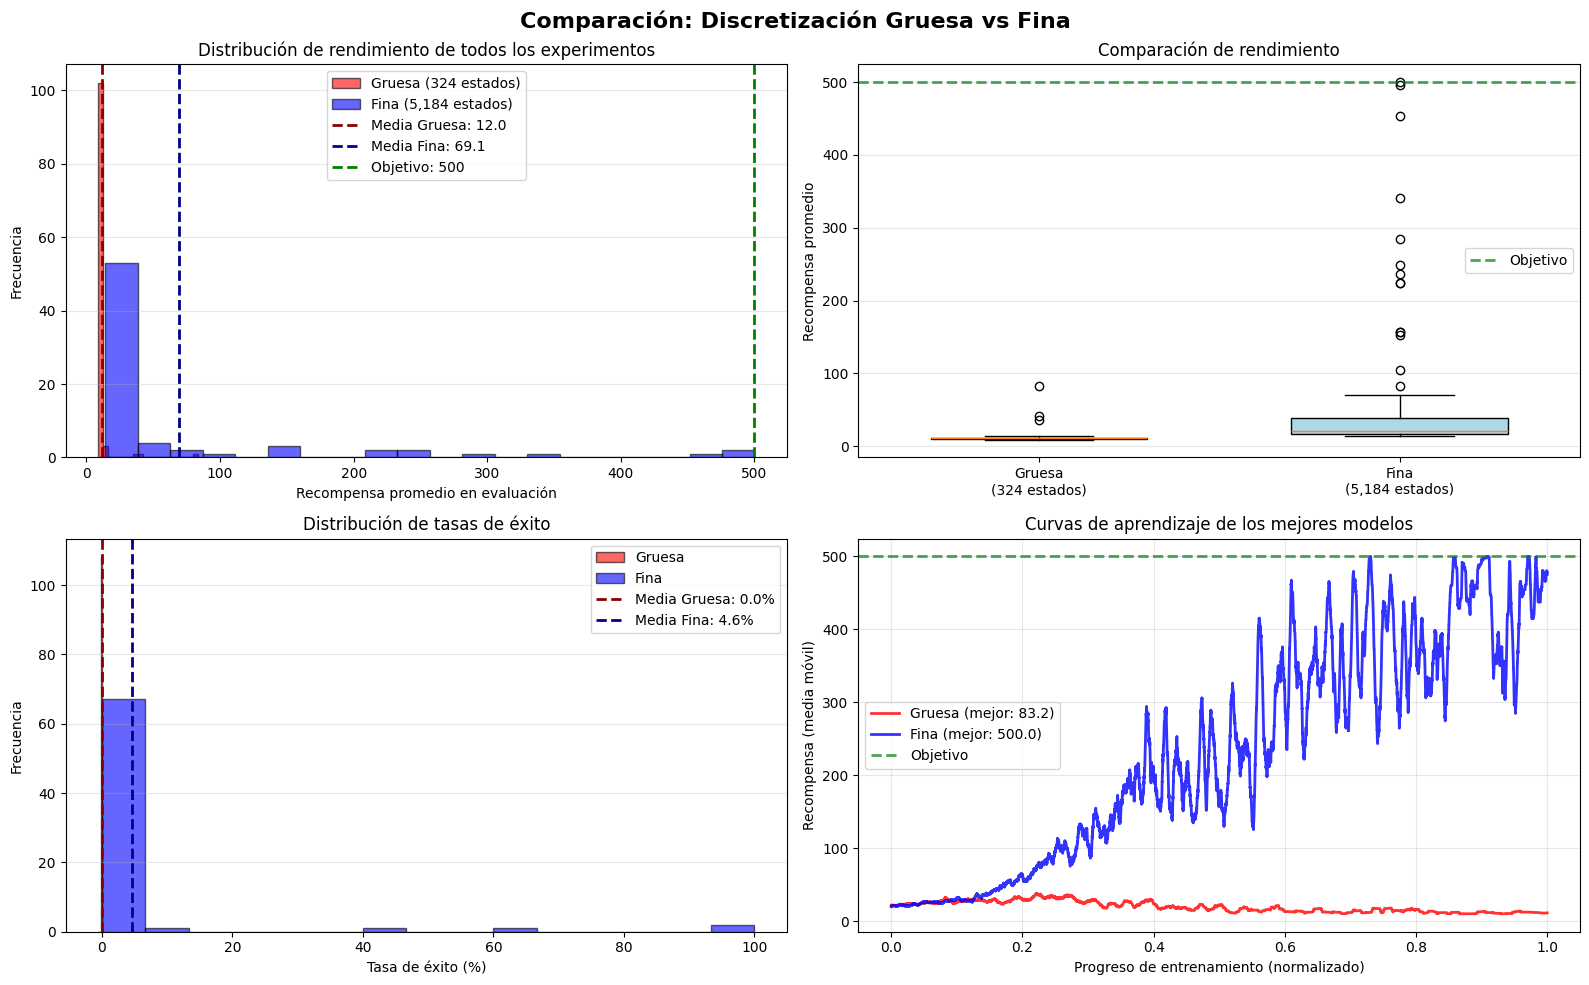

In [99]:
# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Comparación: Discretización Gruesa vs Fina', fontsize=16, fontweight='bold')

# 1. Distribución de recompensas promedio de todos los experimentos
axes[0, 0].hist(coarse_means, bins=20, alpha=0.6, label='Gruesa (324 estados)', 
                color='red', edgecolor='black')
axes[0, 0].hist(fine_means, bins=20, alpha=0.6, label='Fina (5,184 estados)', 
                color='blue', edgecolor='black')
axes[0, 0].axvline(np.mean(coarse_means), color='darkred', linestyle='--', 
                   linewidth=2, label=f'Media Gruesa: {np.mean(coarse_means):.1f}')
axes[0, 0].axvline(np.mean(fine_means), color='darkblue', linestyle='--', 
                   linewidth=2, label=f'Media Fina: {np.mean(fine_means):.1f}')
axes[0, 0].axvline(500, color='green', linestyle='--', linewidth=2, label='Objetivo: 500')
axes[0, 0].set_xlabel('Recompensa promedio en evaluación')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de rendimiento de todos los experimentos')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Box plot comparativo
bp = axes[0, 1].boxplot([coarse_means, fine_means], 
                        labels=['Gruesa\n(324 estados)', 'Fina\n(5,184 estados)'],
                        patch_artist=True,
                        widths=0.6)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightblue')
axes[0, 1].axhline(y=500, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Objetivo')
axes[0, 1].set_ylabel('Recompensa promedio')
axes[0, 1].set_title('Comparación de rendimiento')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Tasa de éxito
success_rates_coarse = [r['success_rate'] * 100 for r in results]
success_rates_fine = [r['success_rate'] * 100 for r in results_fine]

axes[1, 0].hist(success_rates_coarse, bins=15, alpha=0.6, label='Gruesa', 
                color='red', edgecolor='black')
axes[1, 0].hist(success_rates_fine, bins=15, alpha=0.6, label='Fina', 
                color='blue', edgecolor='black')
axes[1, 0].axvline(np.mean(success_rates_coarse), color='darkred', linestyle='--', 
                   linewidth=2, label=f'Media Gruesa: {np.mean(success_rates_coarse):.1f}%')
axes[1, 0].axvline(np.mean(success_rates_fine), color='darkblue', linestyle='--', 
                   linewidth=2, label=f'Media Fina: {np.mean(success_rates_fine):.1f}%')
axes[1, 0].set_xlabel('Tasa de éxito (%)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de tasas de éxito')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Comparación de mejores modelos (curvas de entrenamiento)
window = 100
coarse_best_smooth = np.convolve(best_result['rewards_history'], 
                                 np.ones(window)/window, mode='valid')
fine_best_smooth = np.convolve(best_result_fine['rewards_history'], 
                               np.ones(window)/window, mode='valid')

# Normalizar índices para comparación justa
coarse_x = np.linspace(0, 1, len(coarse_best_smooth))
fine_x = np.linspace(0, 1, len(fine_best_smooth))

axes[1, 1].plot(coarse_x, coarse_best_smooth, linewidth=2, 
                label=f'Gruesa (mejor: {best_result["eval_mean"]:.1f})', color='red', alpha=0.8)
axes[1, 1].plot(fine_x, fine_best_smooth, linewidth=2, 
                label=f'Fina (mejor: {best_result_fine["eval_mean"]:.1f})', color='blue', alpha=0.8)
axes[1, 1].axhline(y=500, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Objetivo')
axes[1, 1].set_xlabel('Progreso de entrenamiento (normalizado)')
axes[1, 1].set_ylabel('Recompensa (media móvil)')
axes[1, 1].set_title('Curvas de aprendizaje de los mejores modelos')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()